<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_13(1)_EDA_TitanicDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment-13:LGBM and XGBM.

This assignment involves performing exploratory data analysis and building predictive models using
wo different datasets as specified in the problem statement. Initially, the Titanic dataset will be
used to conduct exploratory data analysis (EDA), which includes checking for missing values,
analyzing data distributions using histograms and box plots, and examining relationships between
features and survival through scatter plots and bar plots.

 Following this, the Diabetes dataset will be used for predictive modeling. The data will be
preprocessed by handling missing values and encoding categorical variables where necessary.
The dataset will then be split into training and testing sets, and predictive models will be
built using LightGBM and XGBoost algorithms. These models will be evaluated using appropriate
metrics such as accuracy, precision, recall, and F1-score. Finally, a comparative analysis
will be carried out to assess the performance of both algorithms and interpret their strengths
and weaknesses

### Exploratory Data Analysis (EDA):
1.	Load the Titanic dataset using Python's pandas library.
2.	Check for missing values.
3.	Explore data distributions using histograms and box plots.
4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [ ]:
#import the usual necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb


### 1.	Load the Titanic dataset using Python's pandas library.

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


On physically examining the df.info(), the columns - Name, Sex, Ticket, Cabin, Embarked are object type. Others are numerical.

This can be displayed as below:

In [ ]:
# how to find which are continuous columns and which are categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
continuous_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical columns:", categorical_columns)
print("Continuous columns:", continuous_columns)


Categorical columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
Continuous columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


## 2.	Check for missing values.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


This output from df.isnull().sum() shows the number of missing (NaN) values for each column in the df DataFrame:

PassengerId, Survived, Pclass, Name, Sex, SibSp, Parch, Ticket, Fare: These columns have 0 missing values, meaning they are complete.

Age: This column has 177 missing values.

Cabin: This column has 687 missing values.

Embarked: This column has 2 missing values.

This is crucial information for the next steps in data preprocessing, as we need to decide how to handle these missing values (e.g., imputation, removal).

### Unique value counts in object columns

In [ ]:
object_columns = df.select_dtypes(include=['object']).columns

print("Unique value counts for non-numeric (object) columns:")
for col in object_columns:
    print(f"Column '{col}': {df[col].nunique()} unique values")

Unique value counts for non-numeric (object) columns:
Column 'Name': 891 unique values
Column 'Sex': 2 unique values
Column 'Ticket': 681 unique values
Column 'Cabin': 147 unique values
Column 'Embarked': 3 unique values


### Interpretation of Unique Value Counts for Non-Numeric Columns

-   **'Name' (891 unique values)**: With all values being unique, 'Name' is essentially an identifier. It's not directly useful as a categorical feature for modeling, but you can often extract valuable information from it, such as titles (e.g., Mr., Mrs., Miss, Master) which can be highly predictive.

-   **'Sex' (2 unique values)**: This is a low-cardinality categorical variable (binary: male/female). It's very informative and will likely be one of the most important features for predicting survival. It's suitable for direct encoding (e.g., one-hot encoding or label encoding).

-   **'Ticket' (681 unique values)**: Similar to 'Name', 'Ticket' has very high cardinality, suggesting it's mostly unique identifiers. It's generally not used directly as a feature. Sometimes, patterns or prefixes in ticket numbers can be extracted as features, but this requires careful analysis.

-   **'Cabin' (147 unique values)**: While it has relatively high cardinality, the first letter of the 'Cabin' often represents the deck (e.g., 'C' for C-deck). This can be a useful feature after extraction and encoding. It's also important to note the high number of missing values for 'Cabin', which will need to be addressed.

-   **'Embarked' (3 unique values)**: This is a low-cardinality categorical variable representing the port of embarkation (C, Q, S). It's a useful feature for modeling and can be directly encoded.

## 3.	Explore data distributions using histograms and box plots.

Both histograms and box plots are applied to continuous numerical data.

 Histograms are used to understand the distribution of the data, such as its shape, spread, and skewness.

 Box plots, on the other hand, summarize the data using the median, quartiles, and interquartile range (IQR), and are particularly useful for identifying the spread of the data and detecting outliers.

 The PassengerId variable does not contribute to distributional analysis, visualization (such as boxplots), or predictive modeling, since it functions only as a unique identifier without analytical significance.

 Therefore, we drop the PassengerId column from the dataset.

In [ ]:
if 'PassengerId' in df.columns:
    df = df.drop('PassengerId', axis=1)
display(df.head())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###Histograms

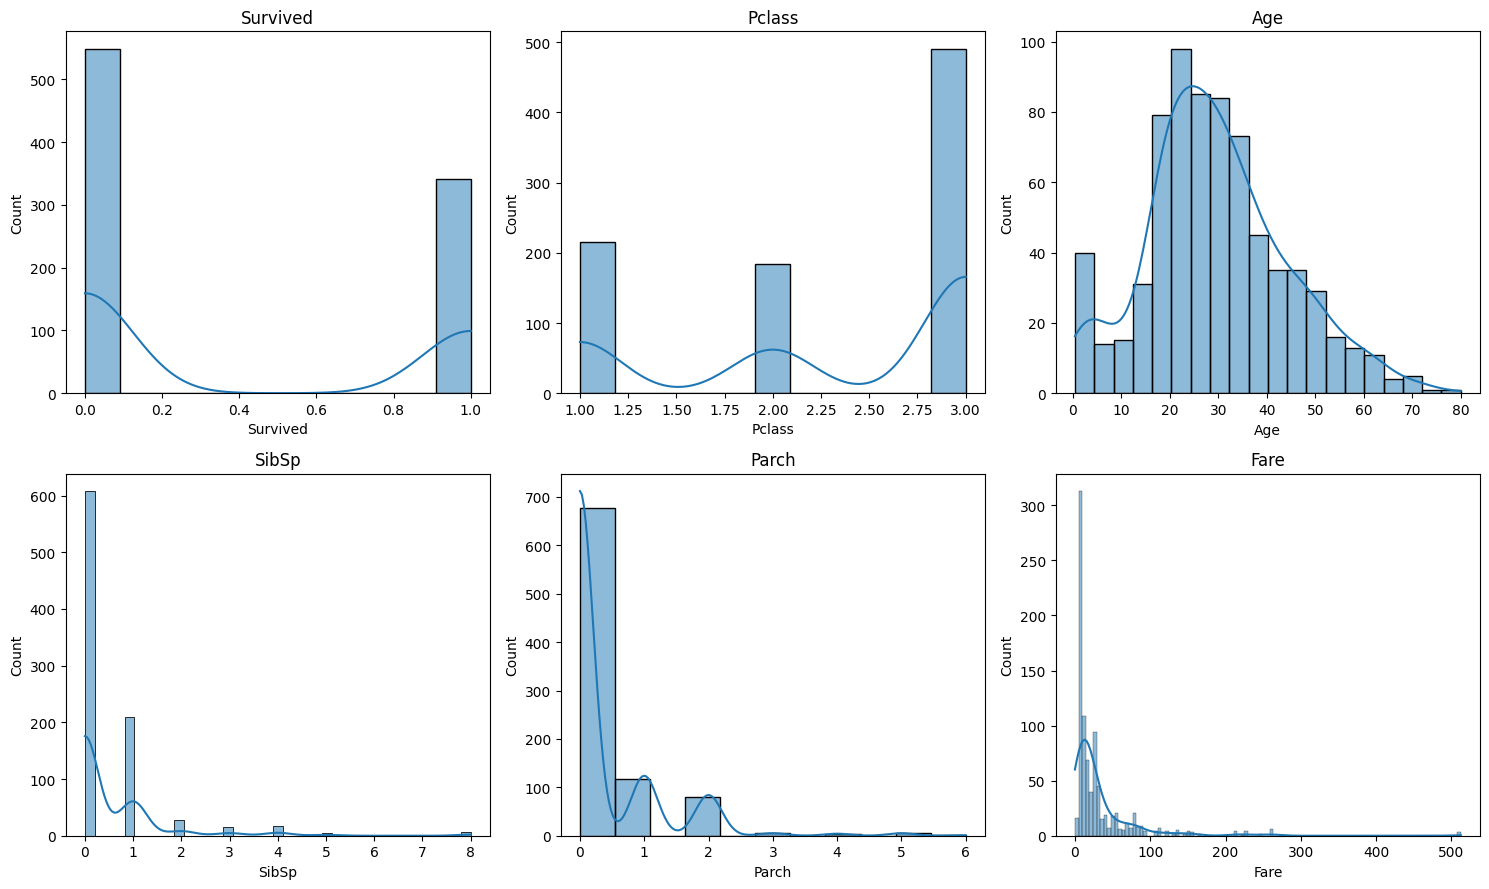

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
#The above is numerical columns after droping PassengerId
plt.figure(figsize=(15, 9))
for i, col in enumerate(numerical_columns):
    plt.subplot(2,3, i+1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


### Interpretation of Histograms

`Survived`: This is a binary categorical variable (0 = Did not survive, 1 = Survived). The distribution shows a clear imbalance, with a higher number of passengers not surviving compared to those who did. This class imbalance is important to consider during model building.

`Pclass`: This is an ordinal categorical variable indicating passenger class (1st, 2nd, 3rd). The majority of passengers belong to the 3rd class, followed by the 1st class, with the 2nd class having slightly fewer passengers. This suggests that most passengers were from lower socioeconomic groups.

`Age`: This is a continuous numerical variable ranging approximately from 0 to 80. The distribution is right-skewed, with most passengers concentrated between 15 and 40 years. There are also very young passengers (infants), and the presence of missing values should be handled carefully during preprocessing.

`SibSp` (Siblings/Spouses Aboard): This is a discrete numerical variable, often treated as categorical. Most passengers have values 0 or 1, indicating they traveled alone or with one companion. Higher values are rare, suggesting that large family groups were uncommon.

`Parch` (Parents/Children Aboard): Similar to SibSp, this is a discrete numerical (categorical-like) variable. A dominant proportion of passengers have a value of 0, meaning they were not traveling with parents or children. Values of 1 and 2 appear moderately, while larger values are very rare.

`Fare`: This is a continuous numerical variable representing ticket price. The distribution is highly right-skewed, with most fares concentrated between 0 and 100, and a few extreme values extending up to around 500. These high values indicate the presence of outliers and suggest significant variation in ticket pricing, likely influenced by passenger class.



### Box Plots

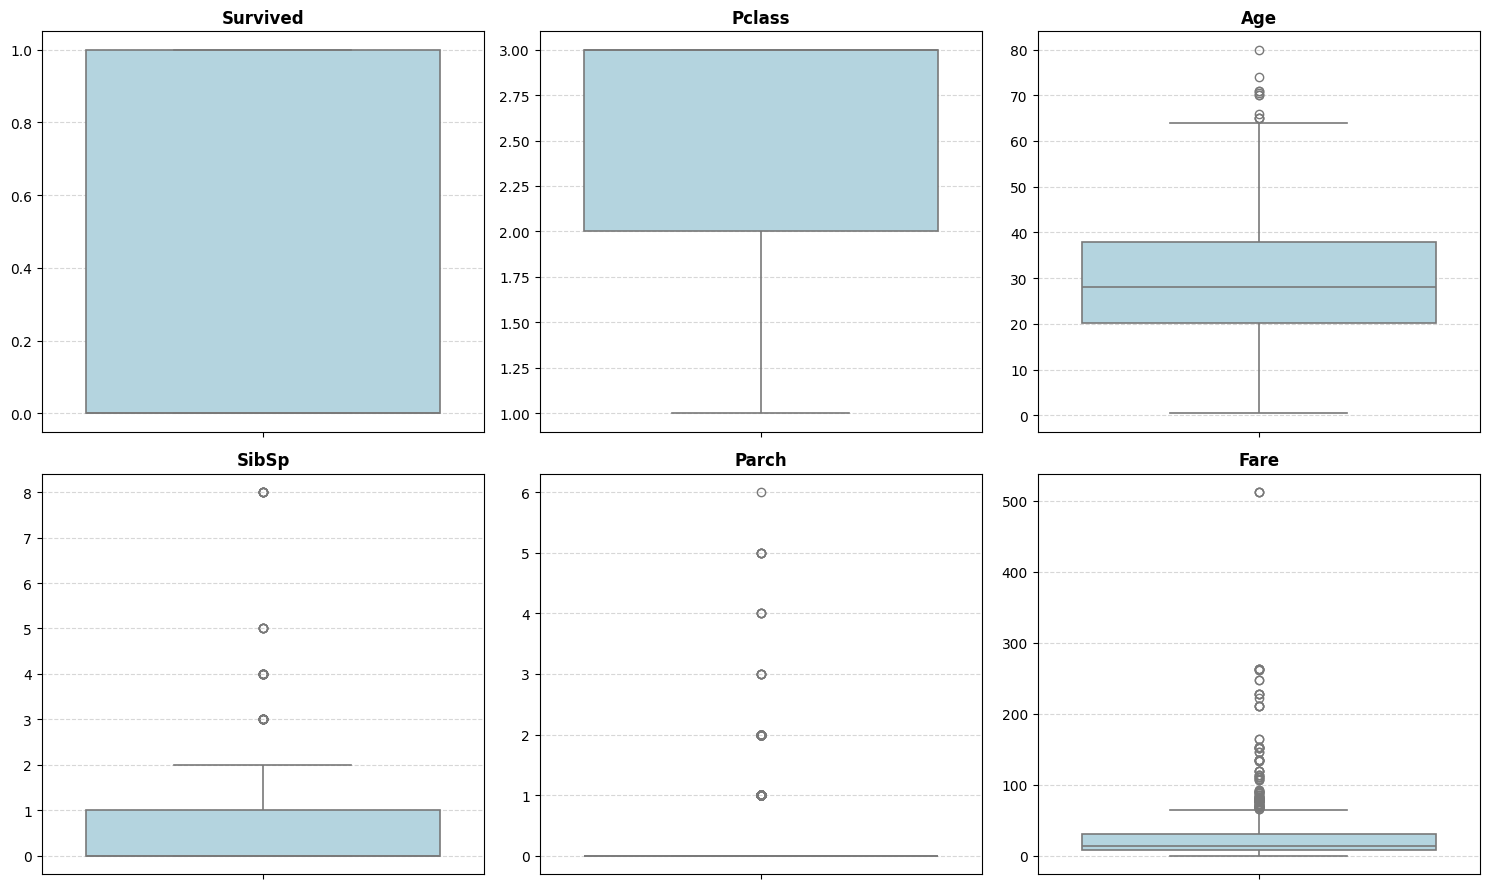

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 9))

for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)

    sns.boxplot(y=df[col], color='lightblue', linewidth=1.2)

    plt.title(col, fontsize=12, fontweight='bold')
    plt.ylabel("")  # remove redundant label
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation of Box Plots

*   **Survived**: This box plot for a binary variable (0 = Not Survived, 1 = Survived) is not ideal for this type of data, as it only shows two distinct points. It indicates the presence and range of the values, but a bar chart would be more appropriate for visualizing the counts of each category.

*   **Pclass**: Similar to `Survived`, `Pclass` is an ordinal categorical variable. The box plot shows three distinct values (1, 2, 3), indicating the different passenger classes. Again, a bar chart would be more effective for understanding the distribution of passengers across these classes.

*   **Age**: The box plot for `Age` shows the median age, the interquartile range (IQR), and potential outliers. The median appears to be around 28-30 years. The box itself (representing the middle 50% of ages) is relatively compact, but there are numerous data points extending far beyond the whiskers, indicating a significant number of outliers, especially among older passengers and very young children, suggesting a wide range of ages on board.

*   **SibSp** (Siblings/Spouses Aboard): The box plot for `SibSp` reveals that the majority of passengers traveled alone or with one sibling/spouse (median at 0). The box is very compressed at the lower end, with many outliers indicating passengers who traveled with 2 or more siblings/spouses. This confirms that large groups are less common.

*   **Parch** (Parents/Children Aboard): Similar to `SibSp`, the `Parch` box plot shows that most passengers did not travel with parents or children (median at 0). Outliers indicate individuals who traveled with 1 or more parents/children. This variable also shows a high concentration at 0 and then spread out with fewer high values.

*   **Fare**: The `Fare` box plot is highly skewed, with the median appearing at a very low value. The majority of fares are concentrated at the lower end, and there are a large number of extreme outliers, some extending up to values around 500. This indicates a significant disparity in ticket prices, with a few passengers paying very high fares, which is consistent with the highly right-skewed histogram.

### Count Plots for Discrete/Categorical Columns with Limited Unique Values

We will now visualize columns that have discrete values and a low number of unique categories using count plots. This includes `Survived`, `Pclass`, `Sex`, `Embarked`, `SibSp`, and `Parch`.

In [ ]:
for col in numerical_columns:
  print(f"Value Counts for {col} is {df[col].nunique()}")

Value Counts for Survived is 2
Value Counts for Pclass is 3
Value Counts for Age is 88
Value Counts for SibSp is 7
Value Counts for Parch is 7
Value Counts for Fare is 248


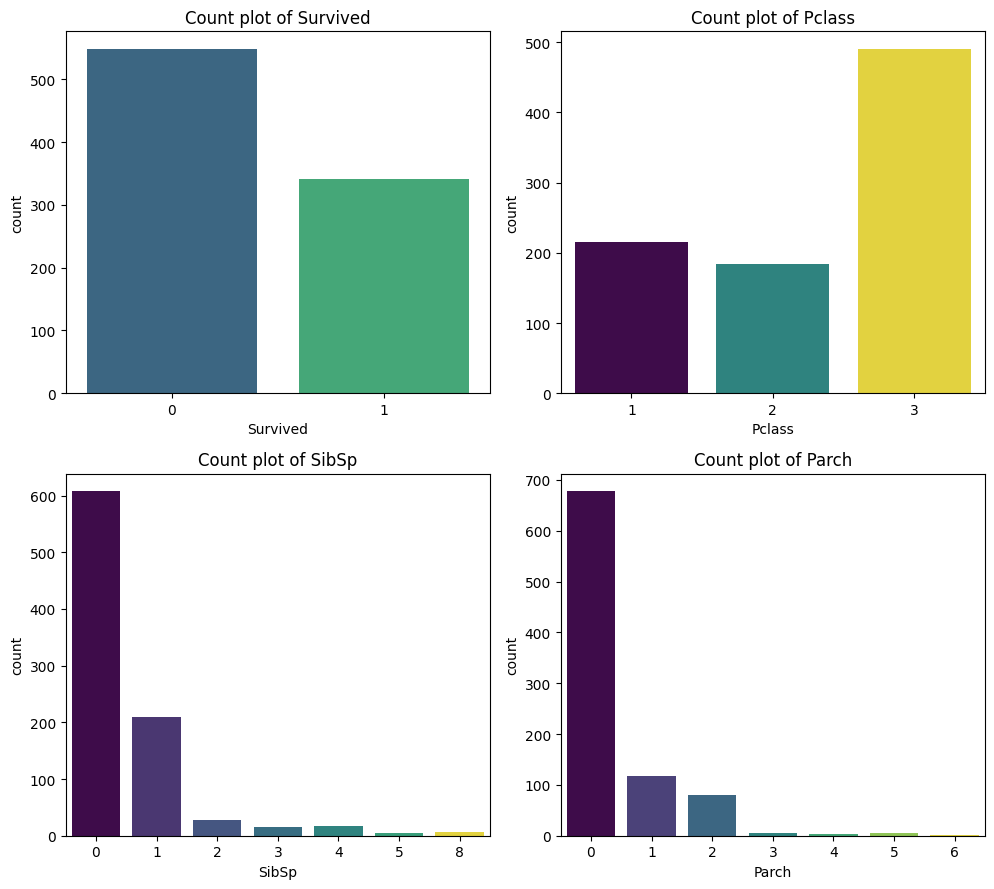

In [ ]:
plt.figure(figsize=(15, 9))
for i, col in enumerate(numerical_columns):

  if df[col].nunique() <= 10:
    plt.subplot(2,3,i+1)
    sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False)
    #df[col].value_counts().plot(kind='bar',color='skyblue')
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

### Interpretation of Count Plot Visuals for Discrete/Categorical Columns

Count plots are highly effective for visualizing the distribution of discrete numerical columns with a limited number of unique values, like `Survived`, `Pclass`, `SibSp`, and `Parch`. Here's why they are useful and what they convey:

*   **Clear Frequencies/Counts**: Unlike histograms (which bin continuous data) or box plots (which summarize central tendency and spread), count plots directly show the count or frequency of each distinct category. This makes it easy to see the absolute and relative numbers of observations in each group.

*   **`Survived`**: The count plot for `Survived` clearly illustrates the class imbalance between those who survived (1) and those who did not (0). You can immediately see the exact number of people in each outcome, which is crucial for understanding the target variable's distribution.

*   **`Pclass`**: This chart effectively displays the distribution of passengers across the different passenger classes (1st, 2nd, 3rd). It quickly reveals that the 3rd class had the highest number of passengers, followed by 1st class, and then 2nd class.

*   **`SibSp` and `Parch`**: For `SibSp` and `Parch`, the count plots highlight the overwhelming majority of passengers who traveled alone (0 siblings/spouses or 0 parents/children). They also show the decreasing frequency as the number of relatives increases, confirming the insights gained from box plots but in a more direct, count-based manner.

*   **Easy Comparison**: Count plots facilitate easy visual comparison between the sizes of different categories, making it straightforward to identify dominant groups or rare occurrences.

In summary, for these types of variables, count plots provide a direct and intuitive representation of category counts, which is often more informative than the statistical summaries provided by box plots or the binned ranges of histograms.

### 4.	Visualize relationships between features and survival using scatter plots and bar plots.

I selected features that are informative, have manageable cardinality, and are suitable for visualization—excluding identifiers and high-missing-value columns.

Target:Survived

Features:Sex, Pclass, Embarked, SibSp, Parch, Age, Fare

In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

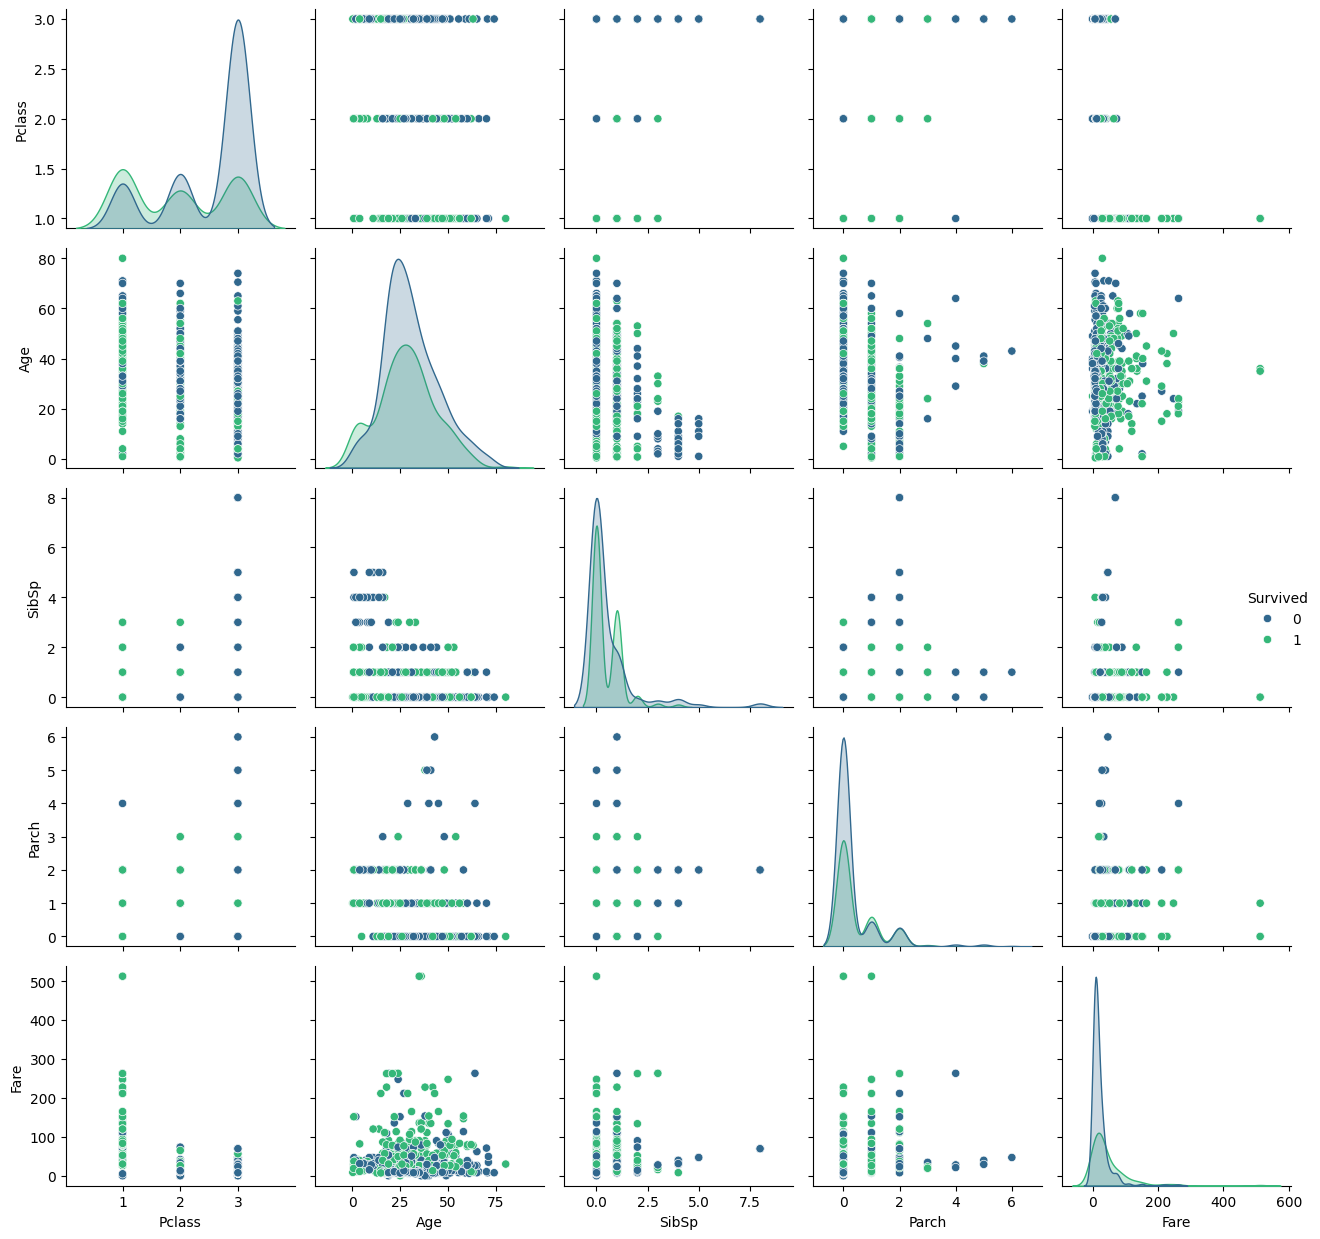

In [ ]:
#pairplot of the numeric columns
sns.pairplot(df,hue='Survived',
    diag_kind='kde',
    palette='viridis')
plt.tight_layout()
plt.show()




### Interpretation of Scatter Plots and Feature Relevance

The pairplot illustrates relationships between all numerical features, with points colored by survival status. However, not all scatter plots are equally informative due to differences in feature types.

Scatter Plots with Discrete Features (Pclass, SibSp, Parch)

Plots involving Pclass, SibSp, and Parch show distinct horizontal or vertical bands because these variables take only a few discrete values.

Pclass vs. Age and Fare:

These plots reveal clear structural patterns. First-class passengers tend to have higher fares and are generally older, while third-class passengers cluster around lower fares and younger ages. Survival patterns indicate that first-class passengers had consistently higher survival rates across age groups, whereas third-class passengers had lower survival.

SibSp and Parch vs. other features:

These variables represent family size and produce layered patterns in scatter plots. Most passengers traveled alone (0 values), spanning all ages and fares. Smaller family groups (e.g., 1–2 members) appear to have slightly better survival rates compared to individuals traveling alone or in larger groups.

While these features are important, their discrete nature limits the effectiveness of scatter plots in revealing smooth relationships or trends.

Why Age and Fare Are Most Informative

Age and Fare are continuous variables, making them more suitable for scatter plot analysis. Their combination provides deeper insights into survival patterns:

Trend Identification:

The distribution of points helps identify how survival varies across age and fare ranges.

Cluster Detection:

Survivors tend to cluster in regions associated with higher fares and younger ages.

Density Insights:

The plot highlights where most passengers fall and how survival is distributed within those regions.

Feature Selection Insight

Based on the visualization:

Most informative for scatter plots: Age, Fare

Better suited for categorical analysis (bar/count plots): Pclass, SibSp, Parch

In summary, while all features contribute to understanding survival, Age and Fare are the most relevant for continuous relationship analysis, whereas the other variables are more effectively interpreted using categorical visualizations.



For selected scatter plots, I selected continuous numerical features like Age and Fare, as they have meaningful ranges and allow us to observe patterns and relationships with the target variable Survived. I avoided discrete or categorical-like variables such as SibSp and Parch because they have limited unique values and are better suited for bar plots. Pclass can be used cautiously since it is ordinal, but it is generally more interpretable with categorical visualizations.”

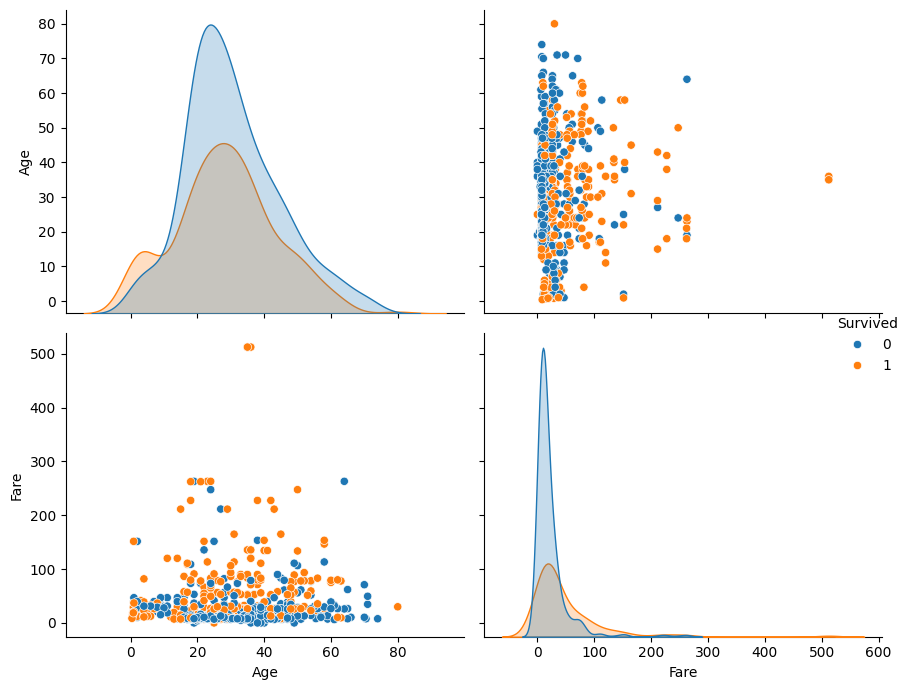

In [ ]:
#Relationship between features-pairplot
#plt.figure(figsize=(6,6))
sns.pairplot(df, vars=['Age','Fare'], hue='Survived',height=3.5,aspect=1.2)
plt.tight_layout()
plt.show()

### Interpretation of Pair Plots for Age, Fare, and Survival

The `pairplot` provides a grid of plots showing relationships between selected numerical features ('Age' and 'Fare'), with the diagonal displaying the distribution of each feature (histograms) and the off-diagonal showing scatter plots of their pairwise relationships, all colored by the 'Survived' status.

#### 1. Diagonal Plots (Histograms by Survival):

*   **Age Distribution:**
    *   The histogram for 'Age' shows the distribution of passenger ages, separated by survival status. We can observe that a higher proportion of younger passengers (especially children) appear to have survived compared to older adults. Conversely, a larger number of passengers in the 20-40 age range who did not survive are evident. This suggests 'Age' is an important factor in survival, with younger individuals having a better chance.

*   **Fare Distribution:**
    *   The histogram for 'Fare' reveals that passengers who paid higher fares have a noticeably higher survival rate. The distribution of non-survivors is heavily concentrated at lower fare values, while survivors are more spread across medium to higher fare ranges. This strongly indicates that 'Fare' (and by extension, likely 'Pclass') is a significant predictor of survival, with wealthier passengers having a better outcome.

#### 2. Off-Diagonal Plots (Scatter Plots by Survival):

*   **Age vs. Fare (and Fare vs. Age) Scatter Plots:**
    *   These plots show the relationship between 'Age' and 'Fare', with each point colored by 'Survived'.
    *   **Low Fare, Low Survival:** There's a dense cluster of points at the lower end of the 'Fare' scale, where many passengers did not survive (blue points). This cluster contains a wide range of ages.
    *   **High Fare, High Survival:** As 'Fare' increases, particularly for fares above a certain threshold (e.g., beyond 100), the proportion of survived passengers (orange points) becomes visibly higher, regardless of age. These higher-fare passengers are generally associated with better survival chances.
    *   **Children and Survival:** We can observe some orange points (survived) among very young ages, often with varying fares, suggesting that being a child might have been a survival advantage, possibly due to 'women and children first' protocols.

**In summary, the pair plots clearly illustrate that both 'Age' and 'Fare' played a crucial role in predicting survival on the Titanic. Higher fares generally correlated with higher survival rates, and younger passengers, especially children, also showed a tendency for better survival.**

### Bar Plots for Categorical and Discrete Features vs. Survival

We will create bar plots to visualize the relationship between selected features and the 'Survived' target variable. For categorical features, bar plots showing the mean survival rate per category are highly effective. We will focus on 'Sex', 'Pclass', 'Embarked', 'SibSp', and 'Parch'.

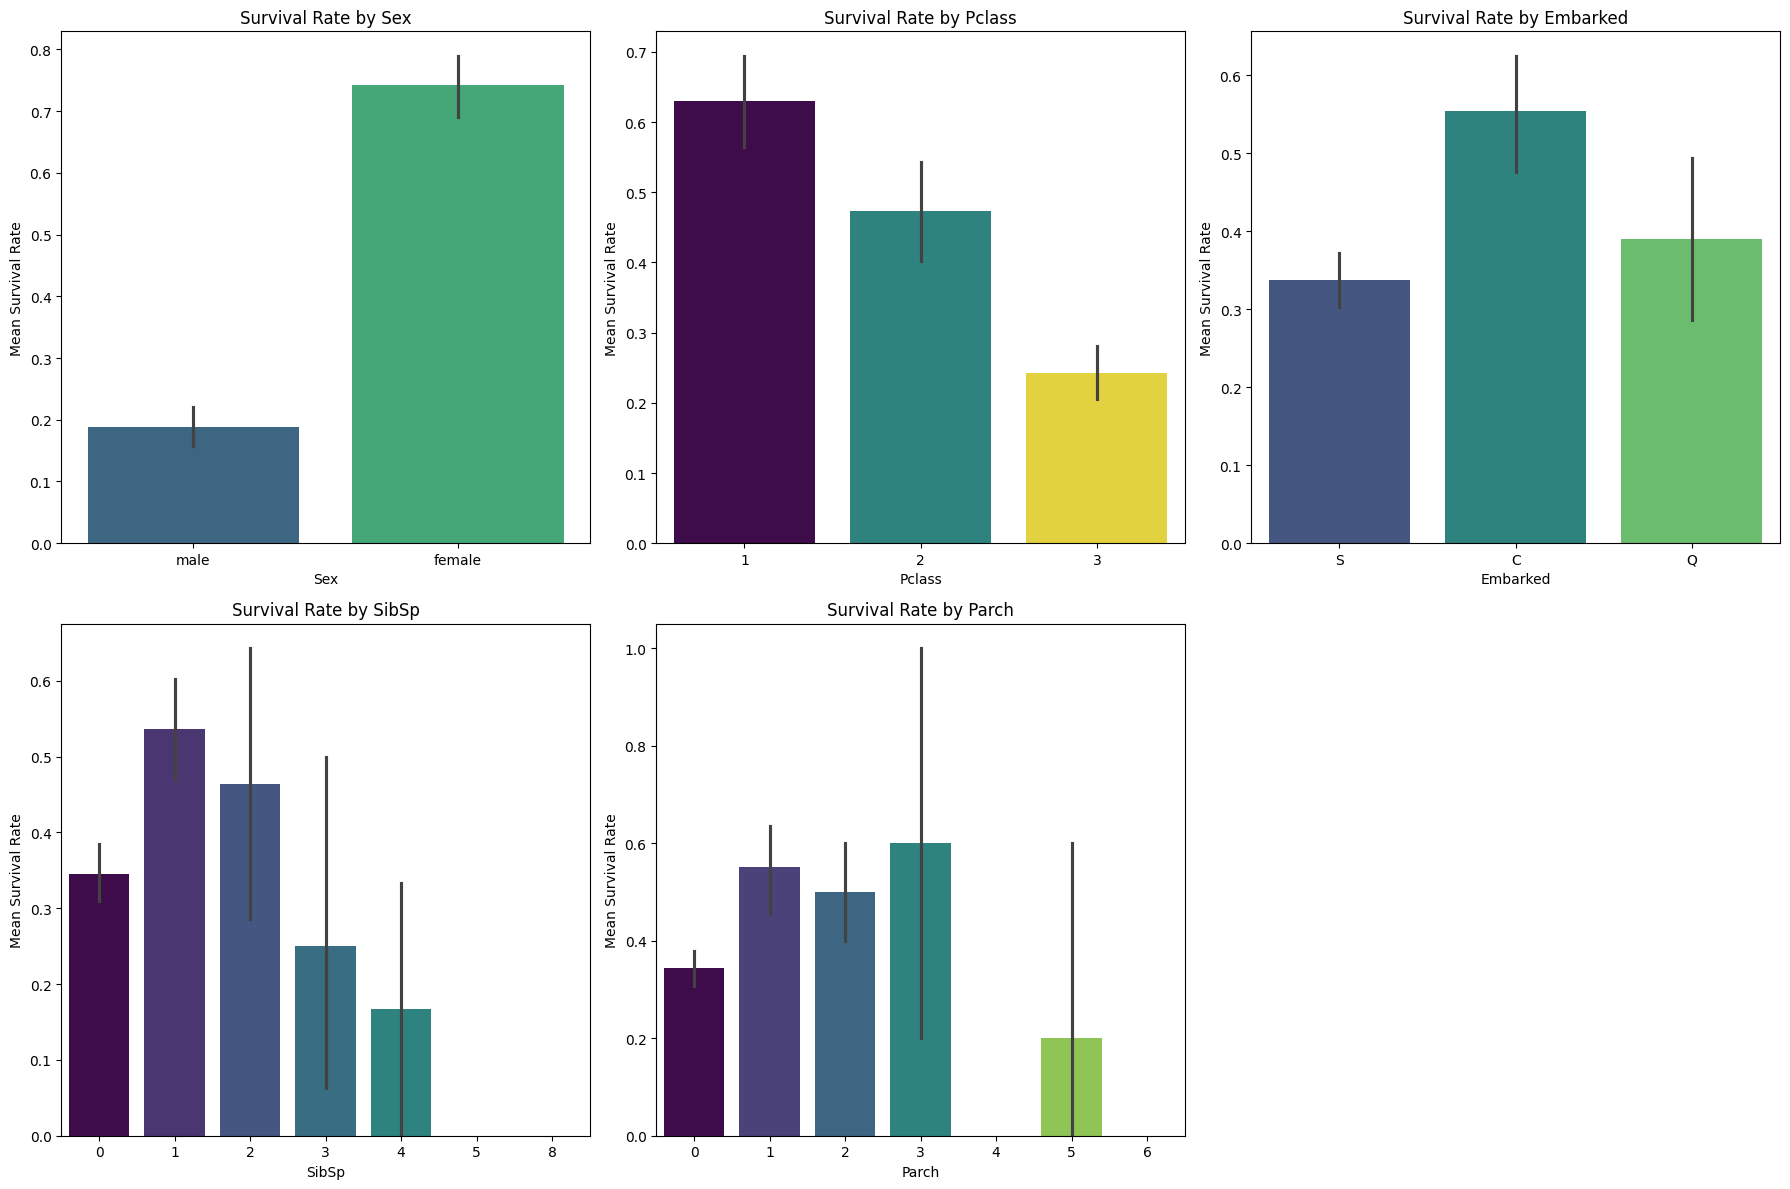

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to plot against 'Survived'
features_for_bar_plots = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']

plt.figure(figsize=(18, 12))

for i, col in enumerate(features_for_bar_plots):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid

    # For 'Sex' and 'Embarked', we use the original object columns
    # For 'Pclass', 'SibSp', 'Parch', they are already numeric but act as categories

    sns.barplot(x=col, y='Survived', data=df, palette='viridis', hue=col, legend=False)
    plt.title(f'Survival Rate by {col}')
    plt.ylabel('Mean Survival Rate')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

The height of each bar effectively represents the mean survival rate for that specific category.

### Mean Survival Rate by category in each column (groupby column)
In seaborn.barplot, when we pass a quantitative variable (like Survived, which is 0 or 1) to the y argument and a categorical variable to the x argument, the function automatically calculates the mean of the y variable for each category in x.

So, in our case, for each gender ('Sex'), 'Pclass', 'Embarked' category, 'SibSp' value and 'Parch' value, the height of the bar represents the average of the 'Survived' column. Since 'Survived' is 0 (did not survive) or 1 (survived), this average directly translates to the proportion of survivors within that category, which is the survival rate.

In [ ]:
mean_survival_by_sex = df.groupby('Sex')['Survived'].mean()
display(mean_survival_by_sex)

,Survived
Sex,
female,0.742038
male,0.188908


`df.groupby(col)['Survived'].mean()` calculates the mean of the 'Survived' column for each unique category within the col column

In [ ]:
for col in features_for_bar_plots:
  mean_survival_by_col = df.groupby(col)['Survived'].mean()
  print(f"\nMean Survival by {mean_survival_by_col}")
  #display(mean_survival_by_col)


Mean Survival by Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Mean Survival by Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Mean Survival by Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Mean Survival by SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

Mean Survival by Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


### Interpretation of Bar Plots

The bar plots visualize the mean survival rate for each category within the selected features. This helps us understand which categories had a higher or lower chance of survival.

*   **Sex**: There's a very clear and striking difference in survival rates based on 'Sex'. **Females had a significantly higher survival rate** compared to males. This aligns with the 'women and children first' protocol observed during the disaster.

*   **Pclass** (Passenger Class): Survival rates show a strong correlation with 'Pclass'. **First-class passengers had the highest survival rate**, followed by second-class, and then third-class passengers had the lowest survival rate. This indicates that socioeconomic status and deck location played a crucial role in survival.

*   **Embarked** (Port of Embarkation): Passengers who embarked from **Cherbourg (C) appear to have a slightly higher survival rate** compared to those from Queenstown (Q) and Southampton (S). While the difference is not as dramatic as 'Sex' or 'Pclass', it suggests some underlying factors related to the passenger demographics from each port, or perhaps their proximity to lifeboats.

*   **SibSp** (Siblings/Spouses Aboard): The relationship here is more nuanced. Passengers with **1 or 2 siblings/spouses had a higher survival rate** than those traveling alone (0 SibSp) or with a larger number of siblings/spouses (3 or more). This might indicate that having a small family unit provided a balance between having support and not being hindered by a very large group.

*   **Parch** (Parents/Children Aboard): Similar to 'SibSp', passengers with **1, 2, or 3 parents/children aboard show a better survival rate** than those with 0 (traveling alone) or a larger number (4 or more). This again points to the advantage of being in a small family group. Families with very many children/parents might have had difficulty in evacuation.

In summary, 'Sex' and 'Pclass' stand out as the strongest predictors of survival based on these bar plots, with 'Embarked', 'SibSp', and 'Parch' also showing significant, albeit more subtle, influences.

## Data Preprocessing:
1.	Impute missing values.
2.	Encode categorical variables using one-hot encoding or label encoding.
3.	If needed you can apply more preprocessing methods on the given dataset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


Based on the df.info() output-

The Columns: Survived, Pclass, Name, Sex, SibSp, Parch, Ticket, and Fare all have 891 non-null values, meaning they are complete and have no missing data.

Columns with Missing Values:

Age: This column has 714 non-null values out of 891 entries, indicating 177 missing values.
Cabin: This column has only 204 non-null values out of 891 entries, indicating a significant number of missing values: 687 missing values.
Embarked: This column has 889 non-null values out of 891 entries, indicating 2 missing values.

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


### Checking for Unusual Characters in Object Columns

This step examines all object (string) columns in the dataset to ensure they contain only expected characters. A regular expression (allowed_pattern) defines the valid set, including alphabets, digits, parentheses, commas, periods, forward slashes, apostrophes, double quotes, hyphens, and spaces.

Although certain columns—such as Name—are not relevant for the modeling process, they are still included in this check to maintain overall data consistency and identify any potential anomalies.

The goal is to detect unexpected or irregular characters that may indicate data entry issues or require additional preprocessing before further analysis or encoding.

In [ ]:
#allowed_pattern = r'^[A-Za-z0-9(),./ ]*$'
allowed_pattern = r'^[A-Za-z0-9(),./\'"\- ]*$'
object_cols = df.select_dtypes(include='object')
print(f"Object columns are:{object_cols.columns}")

for col in object_cols.columns:
    invalid_mask = ~object_cols[col].fillna('').str.match(allowed_pattern)
    #invalid_mask = ~object_cols[col].str.match(allowed_pattern, na=False)
    if invalid_mask.sum() > 0:
        print(col, object_cols[col][invalid_mask].nunique()) # Corrected: removed na=False
    else:
        print(f"No invalid characters found in column {col}")

Object columns are:Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
No invalid characters found in column Name
No invalid characters found in column Sex
No invalid characters found in column Ticket
No invalid characters found in column Cabin
No invalid characters found in column Embarked


### 1. Impute missing values

#### Imputing 'Age' with the Median

 `Age` column distribution is observed to be right-skewed, as seen in the histograms during the EDA phase. When a distribution is skewed, the median is a more robust measure of central tendency than the mean because it is less affected by outliers or extreme values. Using the median helps to preserve the overall distribution of the 'Age' column more accurately than the mean would in such a case.





In [ ]:
# Impute 'Age' with the median, as its distribution is skewed
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Missing values in 'Age' after imputation: {df['Age'].isnull().sum()}")

Missing values in 'Age' after imputation: 0


#### Embarked has only 2 missing values

Imputing 'Embarked' with the Mode

In [ ]:
# Impute 'Embarked' with the mode (most frequent value)
mode_embarked = df['Embarked'].mode()[0] # .mode() returns a Series, so take the first element
#df['Embarked'].fillna(mode_embarked, inplace=True)
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Missing values in 'Embarked' after imputation: {df['Embarked'].isnull().sum()}")

Missing values in 'Embarked' after imputation: 0


### The below code checks radom values in the column

In [ ]:
df['Cabin'].sample(10)

,Cabin
423,NaN
817,NaN
66,F33
62,C83
828,NaN
220,NaN
390,B96 B98
301,NaN
344,NaN
168,NaN


#### Handling 'Cabin' by extracting the first letter and imputing 'U' for Unknown

 A very large proportion of the 'Cabin' values were missing (687 out of 891 entries). Imputing with a statistical measure like the mean or median isn't applicable for categorical text data, and dropping the column entirely would mean losing potential information.

In [ ]:
# Extract the first letter of the 'Cabin' and fill missing values with 'U' (Unknown)
df['Cabin'] = df['Cabin'].astype(str).str[0]
print(f"Missing values in 'Cabin' after imputation: {df['Cabin'].isnull().sum()}")

Missing values in 'Cabin' after imputation: 0


In [ ]:
df['Cabin'].sample(10)

,Cabin
217,n
107,n
768,n
683,n
814,n
455,n
91,n
547,n
485,n
199,n


### Verifying all missing values are handled

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


2.	Encode categorical variables using one-hot encoding or label encoding.

In [ ]:
# list column names and number of unique values
print("Unique values in each column:")
for col in df.columns:
  print(f"{col}:{df[col].nunique()}")

Unique values in each column:
Survived:2
Pclass:3
Name:891
Sex:2
Age:88
SibSp:7
Parch:7
Ticket:681
Fare:248
Cabin:9
Embarked:3


### Dropping the 'Name' column

 The 'Name' column has very high cardinality and serves more as an identifier than a useful feature for direct modeling. Therefore, we will drop it from the DataFrame.

In [ ]:
if 'Name' in df.columns:
    df = df.drop('Name', axis=1)

display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,n,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,n,S
3,1,1,female,35.0,1,0,113803,53.1000,C,S
4,0,3,male,35.0,0,0,373450,8.0500,n,S


In [ ]:
df['Ticket'].sample(10)

,Ticket
171,382652
687,349228
832,2671
307,PC 17758
713,7545
758,363294
851,347060
303,226593
141,347081
263,112059


### Dropping the 'Ticket' column

Similar to the 'Name' column, the 'Ticket' column has very high cardinality and serves primarily as an identifier. For most predictive modeling tasks, the raw ticket number doesn't offer direct, meaningful information for survival prediction. Therefore, it's beneficial to drop this column to reduce dimensionality and avoid unnecessary complexity in the model.

In [ ]:
if 'Ticket' in df.columns:
    #df = df.drop('Ticket', axis=1)
    df = df.drop(columns=['Ticket'])

display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,n,S
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,n,S
3,1,1,female,35.0,1,0,53.1000,C,S
4,0,3,male,35.0,0,0,8.0500,n,S


In [ ]:
df.shape

(891, 9)

In [ ]:
#select columns for which unique values are less than 10 as categorical_columns
categorical_columns = [col for col in df.columns if df[col].nunique() < 10]
print(categorical_columns)

['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Cabin', 'Embarked']


In [ ]:
#unique values in each categorical columns
print("Unique values in each categorical column:")
for col in categorical_columns:
  print(f" {col} : {df[col].unique()}")

Unique values in each categorical column:
 Survived : [0 1]
 Pclass : [3 1 2]
 Sex : ['male' 'female']
 SibSp : [1 0 3 4 2 5 8]
 Parch : [0 1 2 5 3 4 6]
 Cabin : ['n' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
 Embarked : ['S' 'C' 'Q']


### Target Variable: Survived

Survived is the target variable with binary values (0 = No, 1 = Yes). Since it is already in a numerical binary format, no further encoding is required.

### `Age` 'Fare' are continuous columns

### Handling of Pclass, SibSp, and Parch

The columns Pclass, SibSp, and Parch are retained in their original numerical form and do not require additional encoding.

These features possess a natural ordinal or quantitative structure. Pclass represents passenger class (1st, 2nd, 3rd), which follows a clear hierarchy. Similarly, SibSp and Parch denote counts of family members, where higher values indicate greater quantities, preserving meaningful numerical relationships.

Since their existing integer values already capture this order effectively, most machine learning models can directly utilize this information without further transformation. Applying one-hot encoding would unnecessarily increase dimensionality and remove the inherent ordering present in these variables.

Therefore, these columns are treated as numerical features and used as-is in the modeling process.

### Encoding of other Categorical Features

`Sex`

Sex contains two categories: male and female. Since this is a binary categorical variable with no ordinal relationship, it can be encoded using label encoding (e.g., male = 0, female = 1). This is efficient and avoids unnecessary expansion of features.

`Cabin`

Cabin contains multiple categories (e.g., A, B, C, D, E, F, G, T, and 'n' for missing/unknown). These categories do not have a meaningful ordinal relationship. Therefore, one-hot encoding is appropriate to represent each category independently without introducing artificial order.

`Embarked`

Embarked includes three categories: S, C, and Q, representing embarkation ports. As there is no inherent ranking among these categories, one-hot encoding is used to avoid imposing any ordinal relationship.

In [ ]:
#  Label encoding of column 'Sex'
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
if df['Sex'].dtype == 'object':
  df['Sex'] = label_encoder.fit_transform(df['Sex'])
else:
  print("Column 'Sex' is already encoded.")

In [ ]:
display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,n,S
1,1,1,0,38.0,1,0,71.2833,C,C
2,1,3,0,26.0,0,0,7.9250,n,S
3,1,1,0,35.0,1,0,53.1000,C,S
4,0,3,1,35.0,0,0,8.0500,n,S


In [ ]:
# One Hot Encoding of column 'Cabin'
#df = pd.get_dummies(df, columns=['Cabin'], prefix=['Cabin'])

In [ ]:
# One-Hot Encode 'Embarked' and drop the first dummy variable
# This avoids multicollinearity by allowing one category to be represented by all zeros
#df = pd.get_dummies(df, columns=['Embarked'], prefix=['Embarked'], drop_first=True)

#display(df.head())

### One-Hot Encoding 'Embarked' using `sklearn.preprocessing.OneHotEncoder`

To use `OneHotEncoder`, we follow these steps:
1.  **Instantiate `OneHotEncoder`**: We create an instance of the encoder. The `drop='first'` argument will automatically drop the first category for each feature to prevent multicollinearity.
2.  **Fit and Transform**: The encoder learns the unique categories from the 'Embarked' column (`fit`) and then transforms them into one-hot encoded format (`transform`). `df[['Embarked']]` is used because `OneHotEncoder` expects a 2D array.
3.  **Convert to DataFrame**: The output of `transform` is a NumPy array. We convert it back to a pandas DataFrame, using `encoder.get_feature_names_out()` to get meaningful column names.
4.  **Concatenate**: Finally, we concatenate these new one-hot encoded columns with the original DataFrame and drop the original 'Embarked' column.

In [ ]:
df['Embarked'].nunique()

3

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[['Embarked']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
df = df.drop('Embarked', axis=1)
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,n,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,C,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,n,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,C,0.0,1.0
4,0,3,1,35.0,0,0,8.0500,n,0.0,1.0


In [ ]:
df['Cabin'].nunique()

9

In [ ]:
#encoding column 'Cabin'
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['Cabin']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
df = df.drop('Cabin', axis=1)
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_n
0,0,3,1,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,1,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 3.	If needed you can apply more preprocessing methods on the given dataset.

The two continuous columns `Age`, `Fare` needs to be scaled

For the 'Age' and 'Fare' columns, We use RobustScaler. This scaler is particularly effective because both features show skewed distributions and have outliers, as observed during our exploratory data analysis. RobustScaler uses the median and interquartile range for scaling, making it less sensitive to these extreme values compared to other scalers like StandardScaler.


In [ ]:
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
scaler = RobustScaler()

# Select the columns to be scaled
#columns_to_scale = ['Age', 'Fare']

# Apply RobustScaler to the selected columns
#df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']] )

print("DataFrame after Robust Scaling of 'Age' and 'Fare' columns:")
display(df.head())

DataFrame after Robust Scaling of 'Age' and 'Fare' columns:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_n
0,0,3,1,-0.461538,1,0,-0.312011,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,0,0.769231,1,0,2.461242,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,0,-0.153846,0,0,-0.282777,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,0,0.538462,1,0,1.673732,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,1,0.538462,0,0,-0.277363,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### Robust Scaler

​X_scaled = (X-median)/(Q3-Q1)

Robust scaling centers data using the median and scales it based on the interquartile range (IQR), making it less sensitive to outliers compared to standard normalization methods.

## Conclusion (Titanic Dataset – EDA & Preprocessing)

The exploratory data analysis of the Titanic dataset provided valuable insights into the structure, quality, and underlying patterns of the data. Missing values were identified in key features such as Age, Cabin, and Embarked, and appropriate imputation techniques were applied to ensure data completeness.

Visual analysis using histograms and box plots revealed the distribution of numerical variables and helped detect outliers, while bar plots and scatter plots highlighted meaningful relationships between features and survival outcomes. Notably, factors such as gender, passenger class, and fare showed strong influence on survival probability, indicating their importance in predictive modeling.

Categorical variables were effectively transformed using encoding techniques, enabling compatibility with machine learning algorithms. Overall, the preprocessing steps improved data quality and ensured that the dataset is well-prepared for model development.

This phase establishes a strong foundation for building reliable predictive models by addressing data inconsistencies and uncovering key feature relationships.

### Note on Next Phase

The second part of the assignment, which involves building and comparing LightGBM and XGBoost models using the diabetes dataset, will be carried out in a separate file to maintain clarity and modularity of the analysis.